# Wisesight Sentiment — Preprocessing & EDA

This notebook loads the **Wisesight Sentiment** Thai social-media dataset, explores it (class balance, text length, emoji/word usage), runs a data quality check, applies a Thai-aware text cleaning pipeline, and saves the processed splits to disk.

## 1. Setup & Environment
Mount Google Drive, set the working directory, and download/register a Thai font (Sarabun) so Thai text renders correctly in matplotlib plots later on.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!wget -O Sarabun-Regular.ttf \
https://github.com/google/fonts/raw/main/ofl/sarabun/Sarabun-Regular.ttf

--2026-06-18 18:38:55--  https://github.com/google/fonts/raw/main/ofl/sarabun/Sarabun-Regular.ttf
Resolving github.com (github.com)... 140.82.116.4
Connecting to github.com (github.com)|140.82.116.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/google/fonts/main/ofl/sarabun/Sarabun-Regular.ttf [following]
--2026-06-18 18:38:55--  https://raw.githubusercontent.com/google/fonts/main/ofl/sarabun/Sarabun-Regular.ttf
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 90220 (88K) [application/octet-stream]
Saving to: ‘Sarabun-Regular.ttf’

Sarabun-Regular.ttf 100%[===================>]  88.11K  --.-KB/s    in 0.01s   

2026-06-18 18:38:56 (8.19 MB/s) - ‘Sarabun-Regular.ttf’ saved [90220/90220]



In [4]:
import matplotlib.font_manager as fm
from matplotlib import rcParams
import os

font_path = os.path.abspath("Sarabun-Regular.ttf")

# register font
fm.fontManager.addfont(font_path)

# create font property
thai_font = fm.FontProperties(fname=font_path)

print("Thai font loaded:", thai_font.get_name())

Thai font loaded: Sarabun


Install the Python packages used throughout this notebook (HuggingFace `datasets`, `pythainlp` for Thai NLP, plotting libraries, `wordcloud`, and `scikit-learn`).

In [5]:
!pip install -q datasets pythainlp matplotlib seaborn wordcloud emoji scikit-learn

## 2. Imports
Core libraries used across the rest of the notebook.

In [6]:
from datasets import load_dataset
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from pythainlp.tokenize import word_tokenize
from pythainlp.corpus.common import thai_stopwords
from pythainlp.util import normalize as thai_normalize
import numpy as np
import emoji
import re
from collections import Counter
from wordcloud import WordCloud
import os
import json

## 3. Load Dataset
Download the Wisesight Sentiment dataset (train / validation / test splits) from the HuggingFace Hub.

In [7]:
ds = load_dataset("pythainlp/wisesight_sentiment")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


## 4. Configuration: Labels & Color Palette
Map the raw integer labels to readable class names and define a consistent color palette used in every chart below.

In [8]:
PALETTE = {"pos": "#2ecc71", "neg": "#e74c3c", "neu": "#3498db", "q": "#f39c12"}
LABEL_MAP = {0: "neg", 1: "neu", 2: "pos", 3: "q"}

## 5. Build DataFrames
Convert each HuggingFace split into a pandas DataFrame with a human-readable label column, and concatenate them into one `full_df` for dataset-wide analysis.

In [9]:
def to_df(split):
    df = ds[split].to_pandas()
    df = df.rename(columns={"texts": "text", "category": "label"})
    df["label_name"] = df["label"].map(LABEL_MAP)
    df["split"] = split
    return df

train_df = to_df("train")
val_df   = to_df("validation")
test_df  = to_df("test")
full_df  = pd.concat([train_df, val_df, test_df], ignore_index=True)

print(f"\nDataset loaded ✓")
print(f"  Train      : {len(train_df):,}")
print(f"  Validation : {len(val_df):,}")
print(f"  Test       : {len(test_df):,}")
print(f"  Total      : {len(full_df):,}")
full_df.head(5)


Dataset loaded ✓
  Train      : 21,628
  Validation : 2,404
  Test       : 2,671
  Total      : 26,703


,text,label,label_name,split
0,ไปจองมาแล้วนาจา Mitsubishi Attrage ได้หลังสงกร...,1,neu,train
1,เปิดศักราชใหม่! นายกฯ แถลงข่าวก่อนการแข่งขันศึ...,1,neu,train
2,บัตรสมาชิกลดได้อีกไหมคับ,1,neu,train
3,สนใจ new mazda2ครับ,1,neu,train
4,😍😍,0,neg,train


## 6. Exploratory Data Analysis

### 6.1 Class Distribution
How balanced are the sentiment classes, overall and per split?

Overall class distribution:
  pos    6,811  ( 25.5%)  ████████████
  neg    4,778  ( 17.9%)  ████████
  neu   14,539  ( 54.4%)  ███████████████████████████
  q        575  (  2.2%)  █


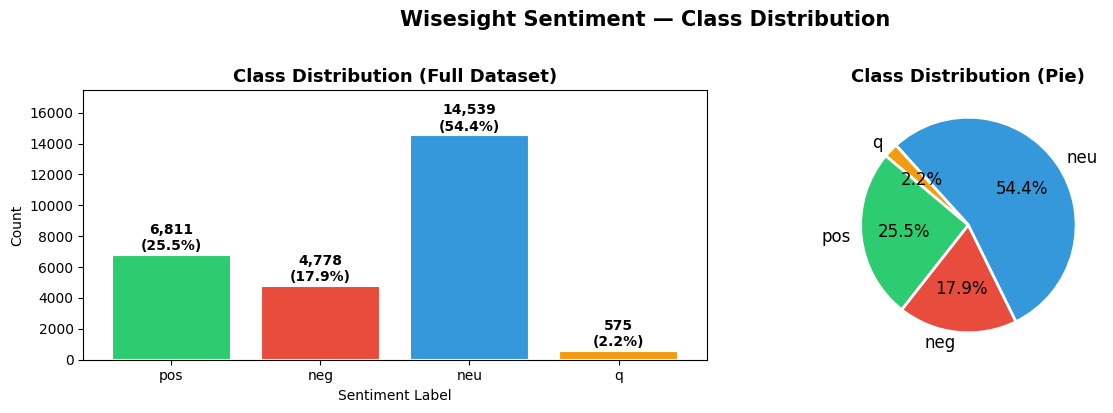

In [10]:
# ── Overall distribution ──────────────────────────────────────────────────────
label_counts = full_df["label_name"].value_counts().reindex(["pos","neg","neu","q"])
label_pct    = (label_counts / len(full_df) * 100).round(1)

print("Overall class distribution:")
for label, cnt in label_counts.items():
    bar = "█" * int(label_pct[label] / 2)
    print(f"  {label:4s}  {cnt:6,}  ({label_pct[label]:5.1f}%)  {bar}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Bar chart
colors = [PALETTE[l] for l in label_counts.index]
bars = axes[0].bar(label_counts.index, label_counts.values, color=colors, edgecolor="white", linewidth=1.5)
for bar, cnt, pct in zip(bars, label_counts.values, label_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f"{cnt:,}\n({pct}%)", ha="center", va="bottom", fontsize=10, fontweight="bold")
axes[0].set_title("Class Distribution (Full Dataset)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Sentiment Label")
axes[0].set_ylabel("Count")
axes[0].set_ylim(0, label_counts.max() * 1.2)

# Pie chart
wedge_props = {"linewidth": 2, "edgecolor": "white"}
axes[1].pie(label_counts.values, labels=label_counts.index, colors=colors,
            autopct="%1.1f%%", startangle=140, wedgeprops=wedge_props,
            textprops={"fontsize": 12})
axes[1].set_title("Class Distribution (Pie)", fontsize=13, fontweight="bold")

plt.suptitle("Wisesight Sentiment — Class Distribution", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
# plt.savefig("../results/eda_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
print("\nClass Distribution Ratios (relative to 'neu' class):")
neu_count = label_counts["q"]
for label, cnt in label_counts.items():
    ratio = cnt / neu_count
    print(f"  {label:4s} : {ratio:.2f}")


Class Distribution Ratios (relative to 'neu' class):
  pos  : 11.85
  neg  : 8.31
  neu  : 25.29
  q    : 1.00


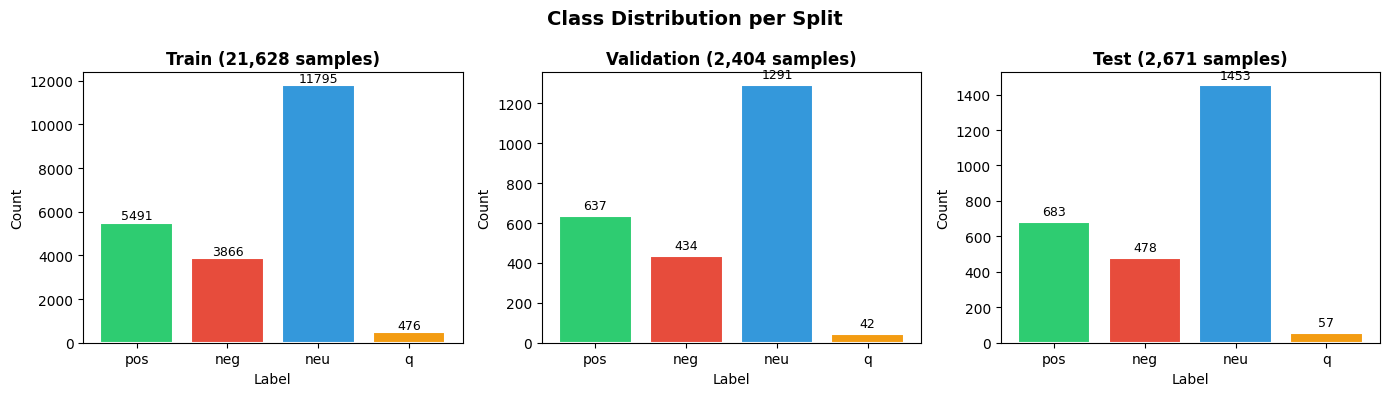

In [12]:
# ── Per-split distribution ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
for ax, (split_name, df) in zip(axes, [("Train", train_df), ("Validation", val_df), ("Test", test_df)]):
    counts = df["label_name"].value_counts().reindex(["pos","neg","neu","q"])
    colors = [PALETTE[l] for l in counts.index]
    bars = ax.bar(counts.index, counts.values, color=colors, edgecolor="white", linewidth=1.5)
    for bar, cnt in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                str(cnt), ha="center", va="bottom", fontsize=9)
    ax.set_title(f"{split_name} ({len(df):,} samples)", fontweight="bold")
    ax.set_xlabel("Label")
    ax.set_ylabel("Count")

plt.suptitle("Class Distribution per Split", fontsize=14, fontweight="bold")
plt.tight_layout()
# plt.savefig("../results/eda_split_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.2 Text Length Analysis
Character and word counts per message, and how they vary by sentiment class.

In [13]:
# Character and word count features
full_df["char_count"]  = full_df["text"].str.len()
full_df["word_count"]  = full_df["text"].apply(
    lambda x: len(word_tokenize(str(x), engine="newmm", keep_whitespace=False))
)

print("Text length statistics (characters):")
print(full_df.groupby("label_name")[["char_count","word_count"]]
      .describe().round(1).to_string())

Text length statistics (characters):
           char_count                                               word_count                                         
                count   mean    std  min   25%   50%    75%     max      count  mean   std  min  25%   50%   75%    max
label_name                                                                                                             
neg            4778.0   58.1   96.4  1.0  13.0  23.0   58.0  1542.0     4778.0  14.4  22.4  1.0  4.0   7.0  15.0  355.0
neu           14539.0  103.3  179.4  1.0  18.0  36.0  109.0  1997.0    14539.0  23.1  37.7  1.0  5.0   9.0  25.0  483.0
pos            6811.0   87.0  101.7  1.0  29.0  59.0  109.0  1978.0     6811.0  22.4  25.3  1.0  8.0  15.0  28.0  482.0
q               575.0   47.2   41.3  8.0  24.0  35.0   57.0   382.0      575.0  12.1  10.1  1.0  6.0   9.0  15.0  100.0


/tmp/ipykernel_18793/2907170483.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_label, labels=["pos","neg","neu","q"],


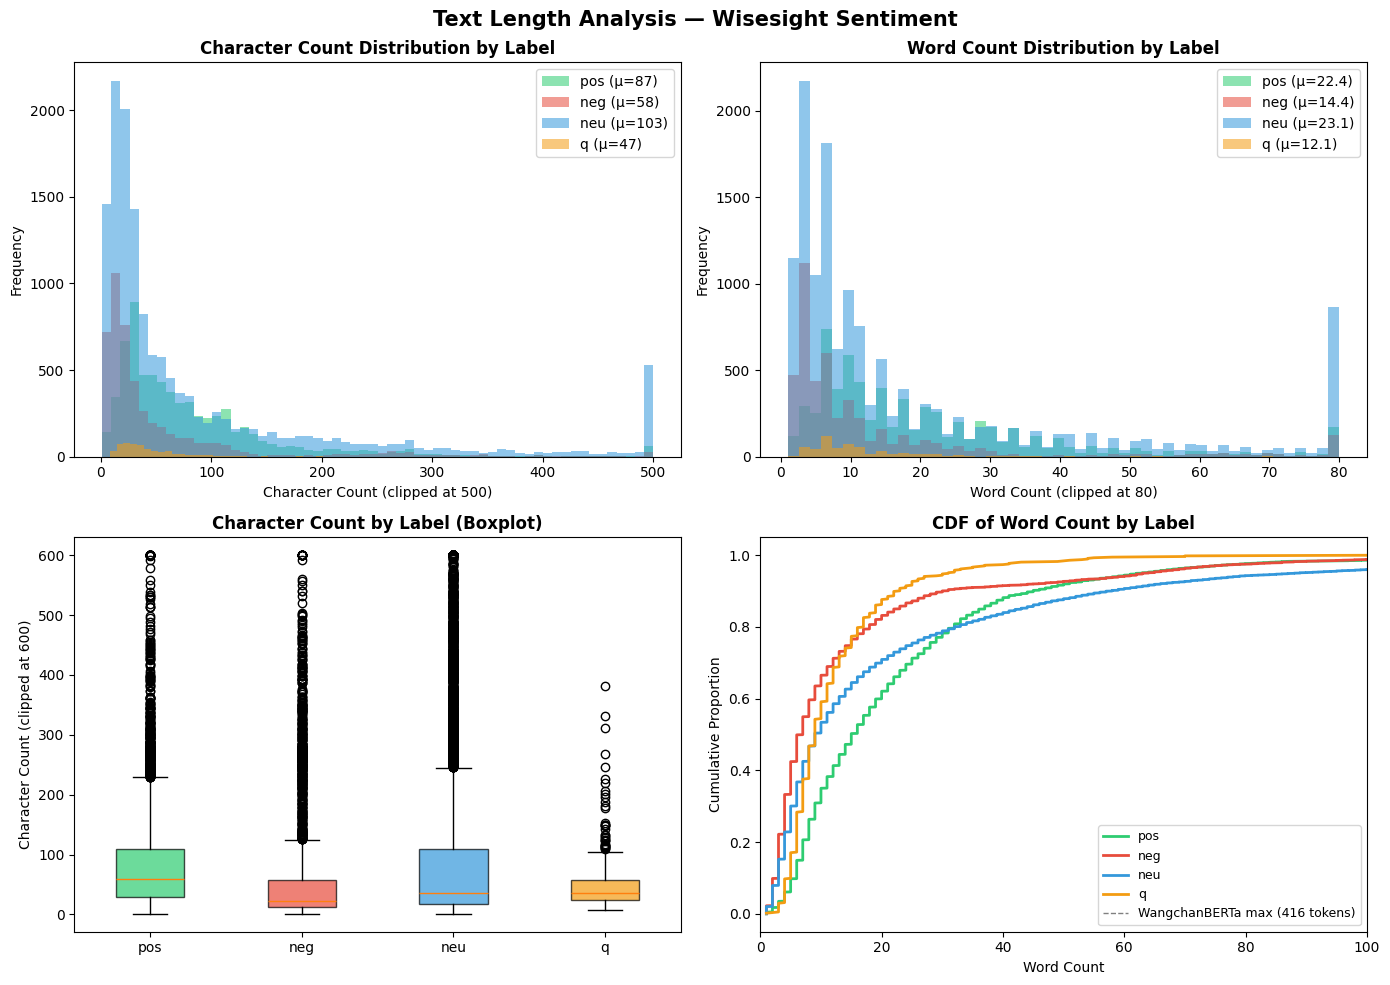

Very short messages (≤3 words): 3,528 (13.2%)
Very long messages (>100 words): 726 (2.7%)


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Char count distribution by label ──
ax = axes[0, 0]
for label in ["pos", "neg", "neu", "q"]:
    subset = full_df[full_df["label_name"] == label]["char_count"]
    ax.hist(subset.clip(upper=500), bins=60, alpha=0.55,
            label=f"{label} (μ={subset.mean():.0f})", color=PALETTE[label], edgecolor="none")
ax.set_title("Character Count Distribution by Label", fontweight="bold")
ax.set_xlabel("Character Count (clipped at 500)")
ax.set_ylabel("Frequency")
ax.legend()

# ── Word count distribution by label ──
ax = axes[0, 1]
for label in ["pos", "neg", "neu", "q"]:
    subset = full_df[full_df["label_name"] == label]["word_count"]
    ax.hist(subset.clip(upper=80), bins=50, alpha=0.55,
            label=f"{label} (μ={subset.mean():.1f})", color=PALETTE[label], edgecolor="none")
ax.set_title("Word Count Distribution by Label", fontweight="bold")
ax.set_xlabel("Word Count (clipped at 80)")
ax.set_ylabel("Frequency")
ax.legend()

# ── Boxplot: char count by label ──
ax = axes[1, 0]
data_by_label = [full_df[full_df["label_name"]==l]["char_count"].clip(upper=600).values
                 for l in ["pos","neg","neu","q"]]
bp = ax.boxplot(data_by_label, labels=["pos","neg","neu","q"],
                patch_artist=True, notch=False)
for patch, label in zip(bp["boxes"], ["pos","neg","neu","q"]):
    patch.set_facecolor(PALETTE[label])
    patch.set_alpha(0.7)
ax.set_title("Character Count by Label (Boxplot)", fontweight="bold")
ax.set_ylabel("Character Count (clipped at 600)")

# ── CDF: word count ──
ax = axes[1, 1]
for label in ["pos", "neg", "neu", "q"]:
    subset = full_df[full_df["label_name"] == label]["word_count"].sort_values()
    cdf = np.arange(1, len(subset)+1) / len(subset)
    ax.plot(subset.values, cdf, label=label, color=PALETTE[label], linewidth=2)
ax.axvline(256, color="gray", linestyle="--", linewidth=1, label="WangchanBERTa max (416 tokens)")
ax.set_xlim(0, 100)
ax.set_title("CDF of Word Count by Label", fontweight="bold")
ax.set_xlabel("Word Count")
ax.set_ylabel("Cumulative Proportion")
ax.legend(fontsize=9)

plt.suptitle("Text Length Analysis — Wisesight Sentiment", fontsize=15, fontweight="bold")
plt.tight_layout()
# plt.savefig("../results/eda_text_length.png", dpi=150, bbox_inches="tight")
plt.show()

short = (full_df["word_count"] <= 3).sum()
long  = (full_df["word_count"] > 100).sum()
print(f"Very short messages (≤3 words): {short:,} ({short/len(full_df)*100:.1f}%)")
print(f"Very long messages (>100 words): {long:,} ({long/len(full_df)*100:.1f}%)")

### 6.3 Text Characteristics (Emoji, English, Numbers)
Flag messages containing emoji, English text, or numbers, and see how these traits correlate with sentiment.

In [15]:
def has_emoji(text):
    return any(c in emoji.EMOJI_DATA for c in str(text))

def count_emojis(text):
    return sum(1 for c in str(text) if c in emoji.EMOJI_DATA)

def has_english(text):
    return bool(re.search(r"[A-Za-z]", str(text)))

def has_numbers(text):
    return bool(re.search(r"[0-9]", str(text)))

def has_thai(text):
    return bool(re.search(r"[\u0E00-\u0E7F]", str(text)))

full_df["has_emoji"]   = full_df["text"].apply(has_emoji)
full_df["emoji_count"] = full_df["text"].apply(count_emojis)
full_df["has_english"] = full_df["text"].apply(has_english)
full_df["has_numbers"] = full_df["text"].apply(has_numbers)
full_df["has_thai"]    = full_df["text"].apply(has_thai)

print("Feature presence by label (% of messages):")
features = ["has_emoji", "has_english", "has_numbers"]
result = full_df.groupby("label_name")[features].mean().mul(100).round(1)
print(result.to_string())

Feature presence by label (% of messages):
            has_emoji  has_english  has_numbers
label_name                                     
neg              12.1         19.6         21.9
neu              10.1         32.5         36.8
pos               8.3         21.6         27.1
q                 2.6         40.7         27.7


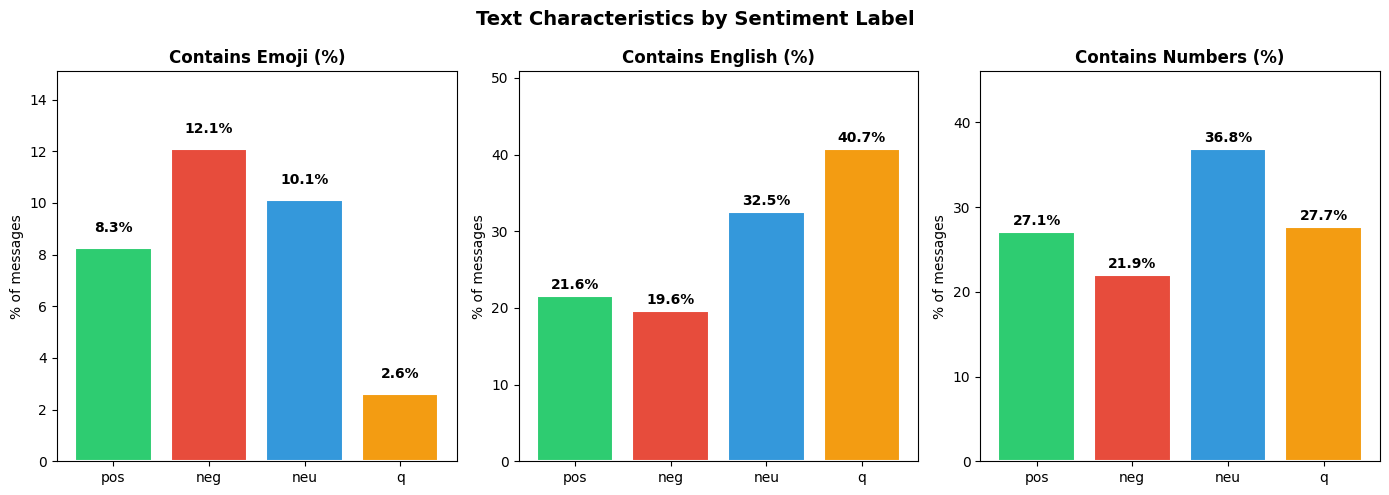

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, feature, title in zip(axes,
    ["has_emoji", "has_english", "has_numbers"],
    ["Contains Emoji (%)", "Contains English (%)", "Contains Numbers (%)"]):
    vals = full_df.groupby("label_name")[feature].mean().mul(100).reindex(["pos","neg","neu","q"])
    colors = [PALETTE[l] for l in vals.index]
    bars = ax.bar(vals.index, vals.values, color=colors, edgecolor="white", linewidth=1.5)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{val:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel("% of messages")
    ax.set_ylim(0, vals.max() * 1.25)

plt.suptitle("Text Characteristics by Sentiment Label", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [17]:
# ── Top emojis ────────────────────────────────────────────────────────────────
all_emojis = [c for text in full_df["text"] for c in str(text) if c in emoji.EMOJI_DATA]
top_emojis = Counter(all_emojis).most_common(20)

print("Top 20 emojis in dataset:")
for em, cnt in top_emojis:
    print(f"  {em}  {cnt:,}")

Top 20 emojis in dataset:
  😂  585
  😭  245
  😍  243
  🏻  239
  ❤  215
  😁  212
  👉  200
  🤣  171
  👍  140
  😘  133
  🎉  128
  🔥  127
  🙏  122
  😊  120
  😅  106
  ➖  103
  📍  99
  😆  98
  ✨  97
  💦  95


### 6.4 Word Frequency Analysis
Tokenize each class's messages (stopwords removed) to find and visualize the most frequent words.

In [18]:
STOPWORDS = thai_stopwords()

def get_tokens(texts, remove_stopwords=True):
    tokens = []
    for text in texts:
        words = word_tokenize(str(text), engine="newmm", keep_whitespace=False)
        words = [w.strip() for w in words if w.strip()]
        if remove_stopwords:
            words = [w for w in words if w not in STOPWORDS and len(w) > 1]
        tokens.extend(words)
    return tokens

print("Tokenizing texts per label")
tokens_by_label = {}
for label in ["pos", "neg", "neu", "q"]:
    texts = full_df[full_df["label_name"] == label]["text"].tolist()
    tokens_by_label[label] = get_tokens(texts)
    print(f"  {label}: {len(tokens_by_label[label]):,} tokens")

Tokenizing texts per label
  pos: 82,151 tokens
  neg: 39,084 tokens
  neu: 198,635 tokens
  q: 3,861 tokens


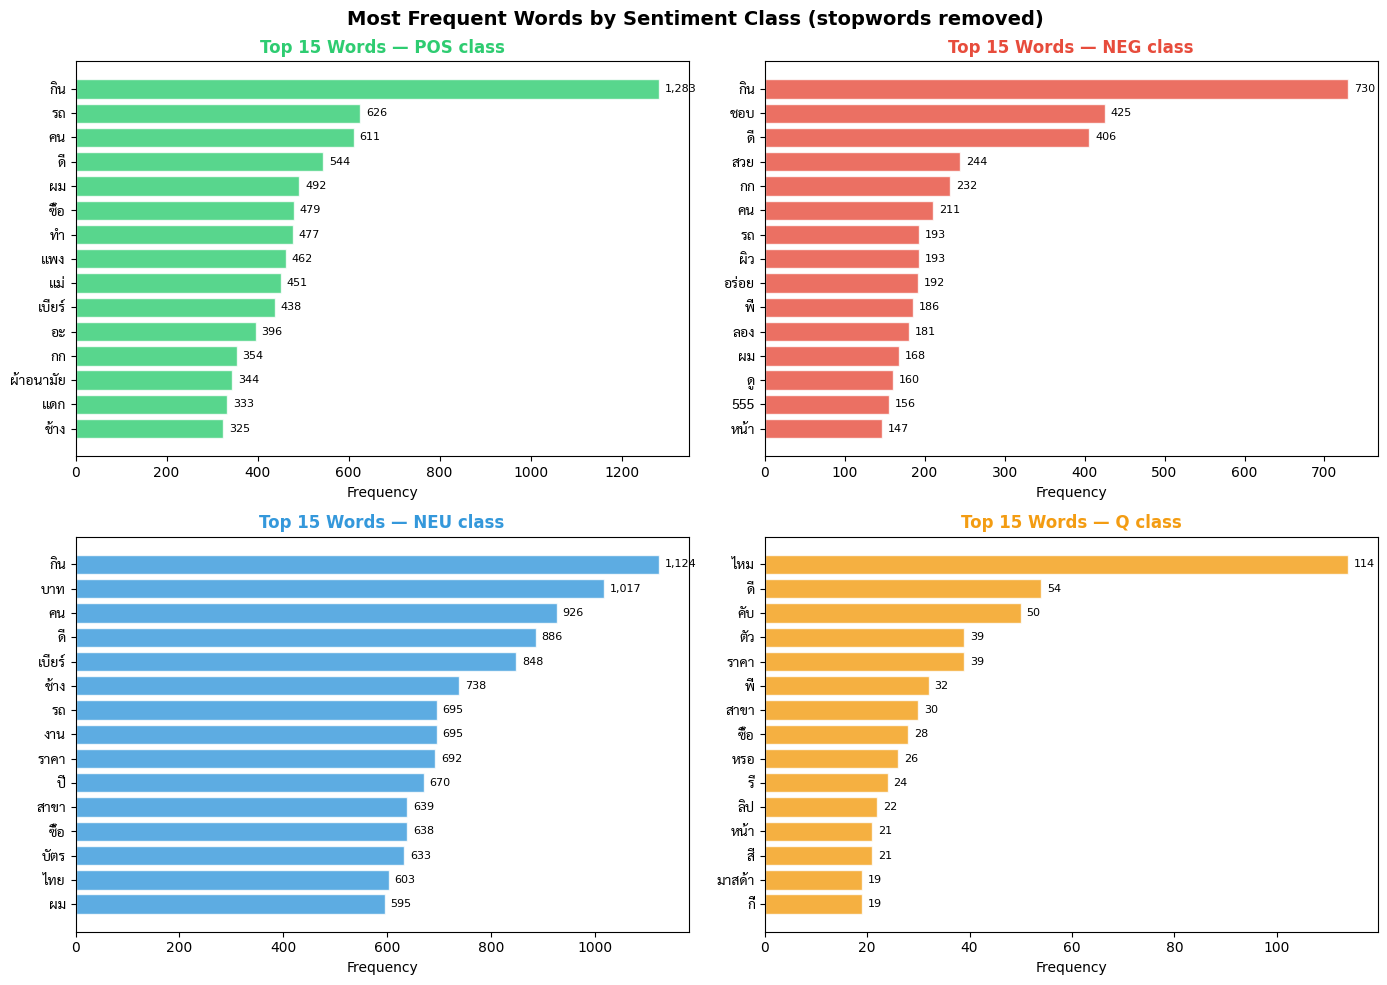

In [19]:
import matplotlib.font_manager as fm
import os

font_path = os.path.abspath("Sarabun-Regular.ttf")
thai_font = fm.FontProperties(fname=font_path)

# ── Top 15 words per label ─────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, label in zip(axes.flat, ["pos", "neg", "neu", "q"]):

    top_words = Counter(tokens_by_label[label]).most_common(15)

    words, counts = zip(*top_words)

    y_pos = range(len(words))

    bars = ax.barh(
        y_pos,
        counts,
        color=PALETTE[label],
        alpha=0.8,
        edgecolor="white"
    )

    ax.set_yticks(y_pos)

    # IMPORTANT
    ax.set_yticklabels(
        words,
        fontsize=11,
        fontproperties=thai_font
    )

    ax.invert_yaxis()

    ax.set_title(
        f"Top 15 Words — {label.upper()} class",
        fontweight="bold",
        color=PALETTE[label]
    )

    ax.set_xlabel("Frequency")

    for bar, cnt in zip(bars, counts):
        ax.text(
            bar.get_width() + counts[0]*0.01,
            bar.get_y() + bar.get_height()/2,
            f"{cnt:,}",
            va="center",
            fontsize=8
        )

plt.suptitle(
    "Most Frequent Words by Sentiment Class (stopwords removed)",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

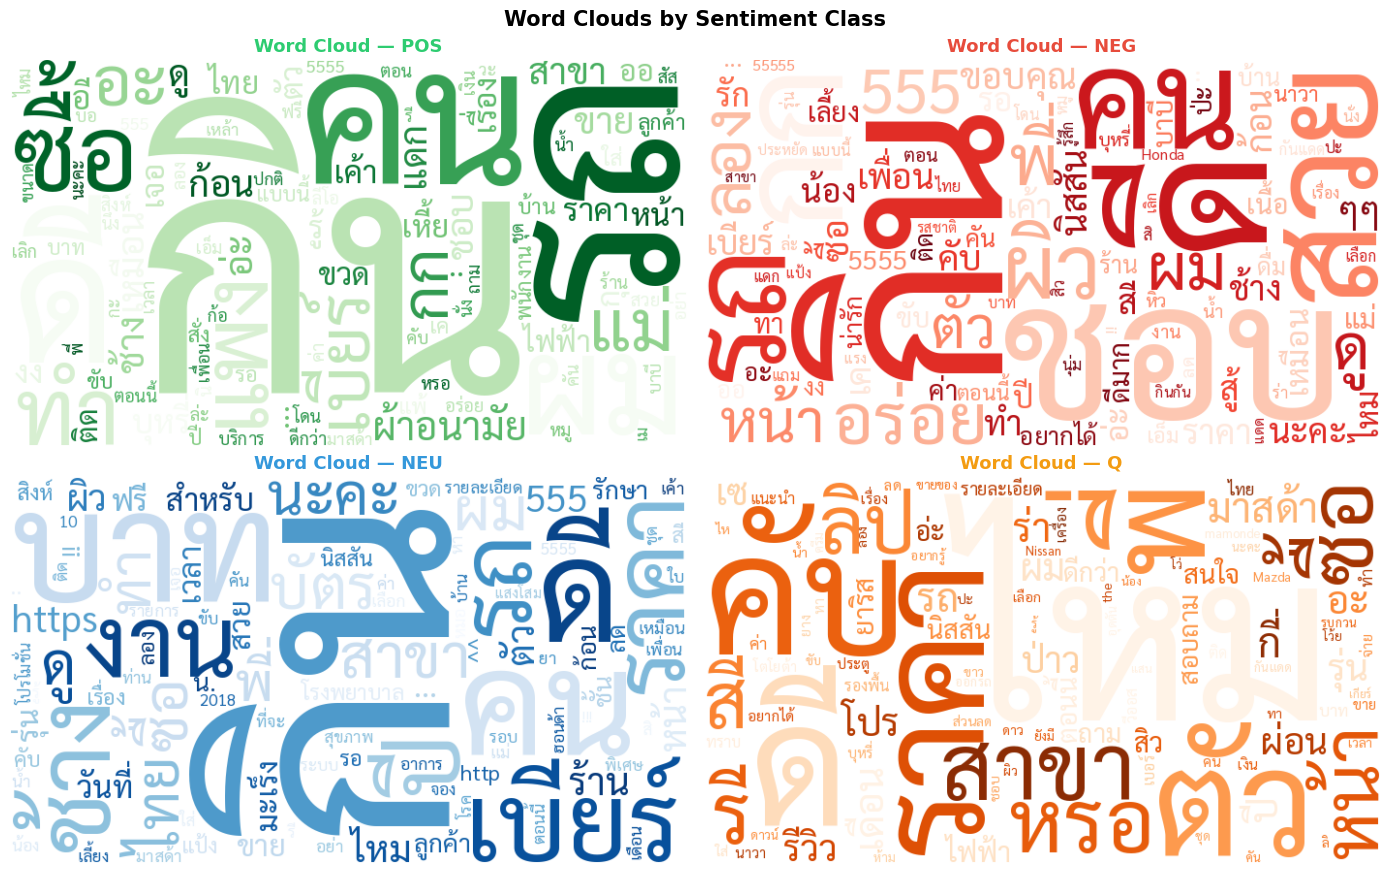

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, label in zip(axes.flat, ["pos", "neg", "neu", "q"]):
    freq = Counter(tokens_by_label[label])          # use frequencies, not raw string

    wc_kwargs = dict(
        width=700, height=400,
        background_color="white",
        max_words=100,
        colormap="Greens"  if label == "pos" else
                 "Reds"    if label == "neg" else
                 "Blues"   if label == "neu" else "Oranges",
        collocations=False,
        min_font_size=10,
        prefer_horizontal=0.7,
        relative_scaling=0.5,                       # prevent one word dominating
    )
    if os.path.exists(font_path):
        wc_kwargs["font_path"] = font_path

    wc = WordCloud(**wc_kwargs).generate_from_frequencies(freq)   # ← key fix
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"Word Cloud — {label.upper()}", fontweight="bold",
                 color=PALETTE[label], fontsize=13)

plt.suptitle("Word Clouds by Sentiment Class", fontsize=15, fontweight="bold")
plt.tight_layout()
# plt.savefig("../results/eda_wordclouds.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.5 Sample Inspection
Spot-check a handful of raw messages from each class.

In [21]:
print("━" * 70)
print("Sample messages per class (5 each)")
print("━" * 70)
for label in ["pos", "neg", "neu", "q"]:
    samples = full_df[full_df["label_name"] == label][["text","char_count","word_count"]].sample(5, random_state=42)
    print(f"\n▶  {label.upper()} ({PALETTE[label]})")
    for _, row in samples.iterrows():
        print(f"   [{row.char_count} chars | {row.word_count} words] {str(row.text)[:120]}")
print("━" * 70)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Sample messages per class (5 each)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

▶  POS (#2ecc71)
   [53 chars | 15 words] show dc บอกจะเปิดตั้งแต่ฉัรอยู่จีน จนกลับมาครบปีแล้ว😂
   [25 chars | 7 words] สาขาเซนลาดไม่ร่วมนะออเจ้า
   [147 chars | 38 words] หายคนมารับแล้วไปส่งที่คอนโดหนึ่งอัตรตรา เมาคืนเมาไอเหี้ย เมาขนาดนี้ล่าสุดก็สี่ปีที่แล้ว พ่อมึงเป็นเจ้าของโรงงานabsoluteห
   [49 chars | 12 words] กินไปน้องรับน้อง คือแบบ สุด จะไม่แดกอีกแล้วแสงโสม
   [28 chars | 8 words] 5555 มึงกุถึงบ้านเงินหมดพอดี

▶  NEG (#e74c3c)
   [2 chars | 1 words] 😋🍜
   [22 chars | 7 words] เทรลเบลเซอร์สวยมากครับ
   [19 chars | 5 words] รอฟันเข้าที่ก่อน555
   [231 chars | 53 words] เห็น อาจารย์ ปิยบุตร อยู่ตรงนั้นแล้วรู้สึกภาคภูมิใจในตัวเองจนอยากจะจูบปากตัวเองจริงๆ ที่เป็นเสียงหนึ่งที่ส่งเขาไปอยู่ตรง
   [19 chars | 5 words] ก่อนหยุดยาว ป่ะๆๆๆๆ

▶  NEU (#3498db)
   [95 chars | 19 words] น้อง ธัญ มีสาขาที่ร่วมรายการดังน

## 7. Data Quality Report
Check for nulls, empty strings, exact duplicates, single-word messages, non-Thai text, and emoji-only messages before cleaning.

In [22]:
print("=" * 50)
print("Data Quality Report")
print("=" * 50)

# Null / empty
nulls    = full_df["text"].isnull().sum()
empties  = (full_df["text"].str.strip() == "").sum()
print(f"\nNull texts   : {nulls}")
print(f"Empty texts  : {empties}")

# Duplicates
exact_dups = full_df.duplicated(subset="text", keep=False).sum()
print(f"Exact duplicates: {exact_dups}")

# Very short texts
very_short = full_df[full_df["word_count"] == 1]
print(f"\nSingle-word messages: {len(very_short):,} ({len(very_short)/len(full_df)*100:.1f}%)")
print("Examples:", very_short["text"].head(5).tolist())

# Non-Thai texts
no_thai = full_df[~full_df["has_thai"]]
print(f"\nMessages with NO Thai characters: {len(no_thai):,}")
if len(no_thai) > 0:
    print("Examples:", no_thai["text"].head(3).tolist())

# Emoji-only messages
thai_re = re.compile(r"[\u0E00-\u0E7F]")
emoji_only = full_df[full_df["text"].apply(
    lambda t: not bool(thai_re.search(str(t))) and has_emoji(t)
)]
print(f"Emoji-only messages: {len(emoji_only):,}")

print("\n" + "=" * 50)

Data Quality Report

Null texts   : 0
Empty texts  : 0
Exact duplicates: 48

Single-word messages: 434 (1.6%)
Examples: ['😍😍', 'หู้ววววว', '☹️', '🤤🤤', '😋🍜']

Messages with NO Thai characters: 244
Examples: ['😍😍', '☹️', 'Cf form Sulwhasoo 920']
Emoji-only messages: 108



## 8. Text Preprocessing
Define and apply a Thai-aware cleaning pipeline (normalization, URL/mention/phone-number removal, whitespace collapsing), then compare text length before vs. after cleaning.

In [23]:
def clean_text(text: str) -> str:
    """
    Thai text cleaning pipeline:
      1. PyThaiNLP normalize   — fix encoding, repeated chars, tone marks
      2. Remove URLs
      3. Remove @mentions and #hashtags
      4. Remove masked phone numbers (from dataset anonymization)
      5. Collapse whitespace
      6. Strip leading/trailing whitespace
    """
    text = str(text)

    # 1. PyThaiNLP normalize (fixes Thai character encoding issues)
    text = thai_normalize(text)

    # 2. Remove URLs
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)

    # 3. Remove @mentions
    text = re.sub(r"@\S+", " ", text)

    # 4. Remove masked phone numbers (e.g. 088-888-8888)
    text = re.sub(r"\d{3}-\d{3}-\d{4}|\d{2}-\d{4}-\d{4}|\d{1}-\d{4}-\d{4}", " ", text)

    # 5. Collapse multiple spaces
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [24]:
# ── Apply cleaning to all splits ──────────────────────────────────────────────
print("Applying preprocessing pipeline...")

for df in [train_df, val_df, test_df, full_df]:
    df["text_clean"] = df["text"].apply(clean_text)
    df["char_count_clean"] = df["text_clean"].str.len()

# Remove rows where cleaning left an empty string
before = {"train": len(train_df), "val": len(val_df), "test": len(test_df)}
train_df = train_df[train_df["text_clean"].str.strip().str.len() > 0].reset_index(drop=True)
val_df   = val_df[val_df["text_clean"].str.strip().str.len() > 0].reset_index(drop=True)
test_df  = test_df[test_df["text_clean"].str.strip().str.len() > 0].reset_index(drop=True)

print(f"Rows removed after cleaning:")
print(f"  train: {before['train'] - len(train_df)} removed → {len(train_df):,} remain")
print(f"  val  : {before['val']   - len(val_df)}   removed → {len(val_df):,} remain")
print(f"  test : {before['test']  - len(test_df)}  removed → {len(test_df):,} remain")

print("\nPreprocessing complete ✓")

Applying preprocessing pipeline...
Rows removed after cleaning:
  train: 5 removed → 21,623 remain
  val  : 0   removed → 2,404 remain
  test : 0  removed → 2,671 remain

Preprocessing complete ✓


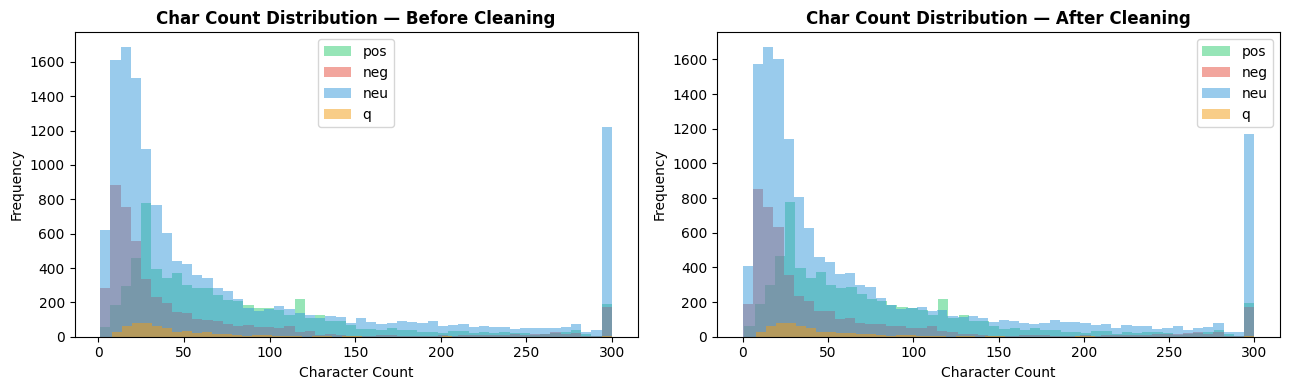

In [25]:
# ── Before vs After length comparison ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, title in zip(axes,
    ["char_count", "char_count_clean"],
    ["Before Cleaning", "After Cleaning"]):
    for label in ["pos", "neg", "neu", "q"]:
        subset = full_df[full_df["label_name"] == label][col]
        ax.hist(subset.clip(upper=300), bins=50, alpha=0.5,
                label=label, color=PALETTE[label], edgecolor="none")
    ax.set_title(f"Char Count Distribution — {title}", fontweight="bold")
    ax.set_xlabel("Character Count")
    ax.set_ylabel("Frequency")
    ax.legend()

plt.tight_layout()
# plt.savefig("../results/eda_before_after_cleaning.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Save Processed Data
Write the cleaned train/val/test splits to CSV and save a summary of the EDA findings as JSON.

In [26]:
os.makedirs("data/processed", exist_ok=True)

train_df[["text_clean", "label", "label_name"]].to_csv("data/processed/train.csv", index=False, encoding="utf-8-sig")
val_df[["text_clean",   "label", "label_name"]].to_csv("data/processed/val.csv",   index=False, encoding="utf-8-sig")
test_df[["text_clean",  "label", "label_name"]].to_csv("data/processed/test.csv",  index=False, encoding="utf-8-sig")

# Save EDA summary
eda_summary = {
    "total_samples": int(len(full_df)),
    "train_samples": int(len(train_df)),
    "val_samples": int(len(val_df)),
    "test_samples": int(len(test_df)),
    "label_distribution": full_df["label_name"].value_counts().to_dict(),
    "avg_char_count": float(full_df["char_count"].mean().round(1)),
    "avg_word_count": float(full_df["word_count"].mean().round(1)),
    "pct_with_emoji": float((full_df["has_emoji"].mean() * 100).round(1)),
    "pct_with_english": float((full_df["has_english"].mean() * 100).round(1))
}
with open("data/processed/eda_summary.json", "w", encoding="utf-8") as f:
    json.dump(eda_summary, f, indent=2, ensure_ascii=False)

print("Saved")

Saved
